### The Hebbian and Anti-Hebbian Neural Network, 2 layers

The new network will have two parts:
- In their first layer, the neurons will be connected with a weight matrix \( W \) between output neurons \( y \) and input neurons \( x \).
$$
\mathbf{y = Wx \in \mathbb{R}^m}
$$
- In their second layer, the output neurons \( y \) will conduct inhibition using between each other with a weight matrix \( V \).
$$
\mathbf{y = Wx + Vy \in \mathbb{R}^m}
$$

The first layer is a Hebbian network, while the second layer is an Anti-Hebbian network.
The equation to update the weights $\mathbf{W}$ is the same as the Hebbian network, while the equation to update the weights $\mathbf{V}$ is the same as the Anti-Hebbian network.

For symmetric, Oja's rule setting:
$$
\mathbf{\Delta W = \eta (yx^T - y^2 W)}
$$

$$
\mathbf{\Delta V = - \gamma (yy^T)}
$$

For asymmetric, Sanger's rule setting:
$$
\mathbf{\Delta W = \eta (yx^T - y^2 W)}
$$

$$
\mathbf{\Delta V = \gamma (yy^T - y^2 V_B), V_B = tril(V)}
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from hebbian.models import HebbianModel, OjaNetwork, SangerNetwork
import hebbian.utils as utils
from typing import Any, Optional

### Model structure

In [2]:
class antiHebbianModel(HebbianModel):
    """
    Two-layer Hebbian / anti-Hebbian network with optional activity-dependent lateral learning.

    rule:
      - "activity_sym"     : ΔV = ε_w (a_i + a_j) ⊙ V  - ε_v yy^T (symmetric)
    """
    def __init__(
        self,
        input_size: int,
        output_size: int,
        learning_rate: float = 0.01,     # η for W
        gamma: float = 0.01,             # γ or ε_v  (anti-Hebbian strength)
        rng: Optional[Any] = None,
        lateral_init: str = "random",
        zero_diagonal: bool = True,
        max_fp_iter: int = 50,
        tol: float = 1e-7,
        # --- NEW: activity-dependent params ---
        eps_w: float = 0.01,             # ε_w (gain on activity leak term)
        activity_alpha: float = 0.01,    # EMA step for a_j: a <- (1-α)a + α y^2
        ) -> None:
        super().__init__(input_size, output_size, learning_rate, rng)
        self.gamma = float(gamma)            # used as ε_v in activity rule

        # Lateral weights V
        if lateral_init == "random":
            self.V = 0.01 * self.rng.standard_normal((self.output_size, self.output_size))
        elif lateral_init == "zeros":
            self.V = np.zeros((self.output_size, self.output_size), dtype=float)
        else:
            raise ValueError("lateral_init must be 'zeros' or 'random'")

        # Activity trace a_j ≈ E[y_j^2]
        self.max_fp_iter = int(max_fp_iter)
        self.tol = float(tol)
        self.activity_alpha = float(activity_alpha)
        self.eps_w = float(eps_w)
        self.a = np.zeros(self.output_size, dtype=float)

        self.zero_diagonal = bool(zero_diagonal)

    def forward(self, x: np.ndarray) -> np.ndarray:
        x = np.asarray(x, dtype=float).reshape(-1)
        if x.shape[0] != self.input_size:
            raise ValueError(f"Input shape {x.shape} != ({self.input_size},)")
        Wx = self.weights @ x
        # fixed-point iteration
        y = Wx.copy()
        for _ in range(self.max_fp_iter):
            y_new = Wx + self.V @ y
            if np.linalg.norm(y_new - y) <= self.tol * (1.0 + np.linalg.norm(y)):
                y = y_new
                break
            y = y_new
        return y

    def step(self, x: np.ndarray) -> np.ndarray:
        x = np.asarray(x, dtype=float).reshape(-1)
        y = self.forward(x)
        # only update the diagonal of the weight matrix
        diag_y = np.diag(y**2)
        # --- W update (multi-neuron Oja; same for all modes) ---
        self.weights += self.learning_rate * (np.outer(y, x) - diag_y @ self.weights)

        # --- Update activity trace a_j ≈ E[y_j^2] (EMA) ---
        # a <- (1-α) a + α (y^2)
        self.a = (1.0 - self.activity_alpha) * self.a + self.activity_alpha * (y ** 2)

        # --- V updates ---
        # Activity-dependent leak:
        # ΔV = ε_w (a_i + a_j) * V  - ε_v y y^T
        A_sum = self.a[:, None] + self.a[None, :]            # (m,m)
        dV = self.eps_w * (A_sum * self.V) - self.gamma * np.outer(y, y)
        self.V += dV
        # make the matrix symmetric
        self.V = 0.5 * (self.V + self.V.T)
        # make the matrix non-positive
        self.V = np.minimum(self.V, 0.0)

        return y


### Test case1: 2D input, 2D output

In [3]:
mu1 = 0.0
std1 = 0.3
mu2 = 0.0
std2 = 0.9
orientation = np.random.random() * np.pi
number_of_neurons = 2
number_of_samples = 2000

# hebbian strength
learning_rate = 0.1
# anti-Hebbian strength
gamma = 0.01
# number of epochs
epochs = 1

{'pcs': array([[-0.99901808, -0.04430438],
        [-0.04430438,  0.99901808]]),
 'eigvals': array([0.79090778, 0.08518469]),
 'mean': array([-3.47222251e-17,  4.91273688e-18])}

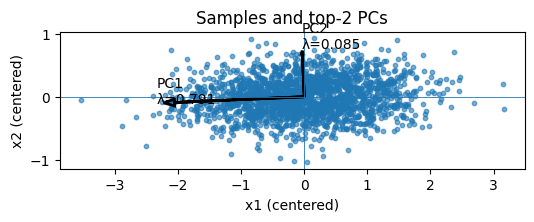

In [4]:
# generate 2D input data
samples_2d = utils.gauss_distrib(orientation, mu1, std1, mu2, std2, number_of_samples, number_of_neurons=2)
utils.plot_samples_and_top2_pcs(samples_2d)

/Users/yat-lok/miniconda3/envs/nn/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2791: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
/var/folders/gz/j8z1vy514q51r1gxg3zf8s_h0000gn/T/ipykernel_28769/113915264.py:62: RuntimeWarning: overflow encountered in square
  diag_y = np.diag(y**2)
/var/folders/gz/j8z1vy514q51r1gxg3zf8s_h0000gn/T/ipykernel_28769/113915264.py:68: RuntimeWarning: overflow encountered in square
  self.a = (1.0 - self.activity_alpha) * self.a + self.activity_alpha * (y ** 2)
/Users/yat-lok/miniconda3/envs/nn/lib/python3.13/site-packages/numpy/_core/numeric.py:995: RuntimeWarning: overflow encountered in multiply
  return multiply(a.ravel()[:, newaxis], b.ravel()[newaxis, :], out)
/var/folders/gz/j8z1vy514q51r1gxg3zf8s_h0000gn/T/ipykernel_28769/113915264.py:51: RuntimeWarning: invalid value encountered in add
  y_new = Wx + self.V @ y
/var/folders/gz/j8z1vy514q51r1gxg3zf8s_h0000gn/T/ipykernel_28769/113915264.py:64: RuntimeWarning: invalid value e

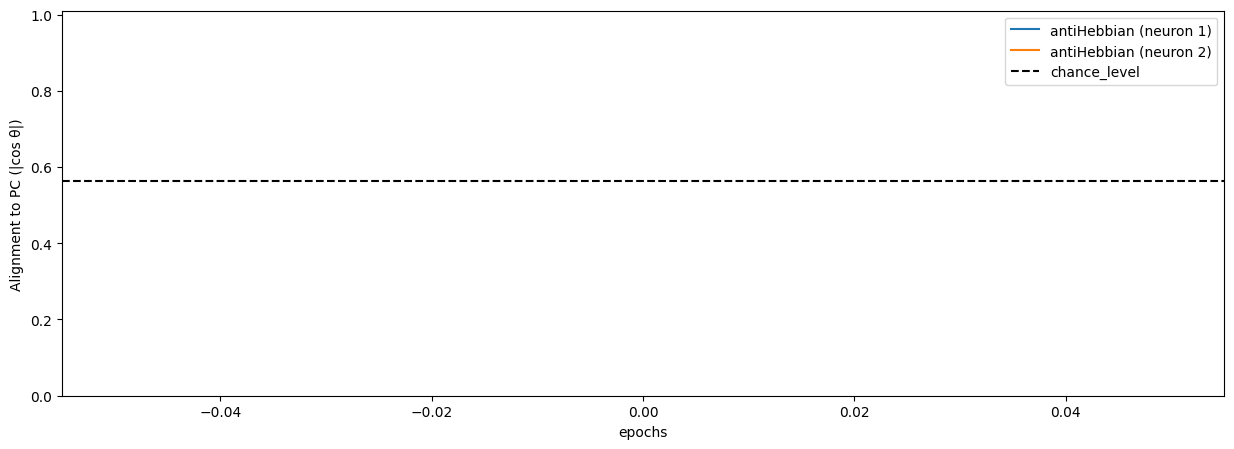

In [5]:
# apply the model
model = antiHebbianModel(input_size=2, output_size=2, learning_rate=learning_rate, gamma=gamma, max_fp_iter=100, tol=1e-6)
# train and test the model
histories_by_model, weights_by_model = utils.training_testing(samples_2d, models = {"antiHebbian": model}, output_size=2, learning_rate=learning_rate, epochs=epochs, method = "epochs", pc_method = "ordered", show_num = None, gamma=gamma)